# Cross-Temporal Split Validation Experiment

## Objective
Test whether a fake news classifier generalizes across time periods by splitting data based on presence of "2016" tokens, training on one split, and testing on the other.

## Approach
1. Split data: articles containing "2016" vs articles without "2016"
2. Train on one temporal split, test on the other
3. Compare with random split baseline to measure generalization gap


## Part 1: Data Loading and Temporal Splitting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ Imports successful")


✓ Imports successful


In [2]:
# Load data directly from CSVs
project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"

print("Loading data...")
train_df = pd.read_csv(processed_dir / "train.csv")
test_df = pd.read_csv(processed_dir / "test.csv")

# Combine into single dataset for temporal splitting
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")


Loading data...
Total samples: 44,439
Columns: ['id', 'title', 'text', 'label']


In [3]:
# Split by presence of "2016" in text
# This creates a temporal proxy: articles mentioning 2016 vs those that don't

def contains_2016(text):
    """Check if text contains '2016' (case-insensitive)"""
    return '2016' in str(text).lower()

df['has_2016'] = df['text'].apply(contains_2016)

# Create temporal splits
df_2016 = df[df['has_2016'] == True].copy()
df_non_2016 = df[df['has_2016'] == False].copy()

print("="*60)
print("TEMPORAL SPLIT BY '2016' PRESENCE")
print("="*60)
print(f"\nArticles WITH '2016':    {len(df_2016):,} ({len(df_2016)/len(df)*100:.1f}%)")
print(f"Articles WITHOUT '2016': {len(df_non_2016):,} ({len(df_non_2016)/len(df)*100:.1f}%)")


TEMPORAL SPLIT BY '2016' PRESENCE

Articles WITH '2016':    8,954 (20.1%)
Articles WITHOUT '2016': 35,485 (79.9%)


In [4]:
# Analyze label distribution in each split
print("="*60)
print("LABEL DISTRIBUTION BY TEMPORAL SPLIT")
print("="*60)

for name, split_df in [("2016 articles", df_2016), ("Non-2016 articles", df_non_2016)]:
    total = len(split_df)
    real_count = (split_df['label'] == 0).sum()
    fake_count = (split_df['label'] == 1).sum()
    
    print(f"\n{name}:")
    print(f"  Real (0): {real_count:,} ({real_count/total*100:.1f}%)")
    print(f"  Fake (1): {fake_count:,} ({fake_count/total*100:.1f}%)")
    print(f"  Fake ratio: {fake_count/total:.3f}")

# Check if there's label imbalance between splits
fake_ratio_2016 = (df_2016['label'] == 1).sum() / len(df_2016)
fake_ratio_non_2016 = (df_non_2016['label'] == 1).sum() / len(df_non_2016)

print(f"\n⚠️  Fake ratio difference: {abs(fake_ratio_2016 - fake_ratio_non_2016):.3f}")
if abs(fake_ratio_2016 - fake_ratio_non_2016) > 0.1:
    print("   WARNING: Significant label distribution shift between splits!")


LABEL DISTRIBUTION BY TEMPORAL SPLIT

2016 articles:
  Real (0): 4,161 (46.5%)
  Fake (1): 4,793 (53.5%)
  Fake ratio: 0.535

Non-2016 articles:
  Real (0): 25,400 (71.6%)
  Fake (1): 10,085 (28.4%)
  Fake ratio: 0.284

⚠️  Fake ratio difference: 0.251


## Part 2: Feature Engineering (TF-IDF)

In [5]:
# Further split each temporal group into train/test for within-split evaluation
# This gives us both within-split and cross-split evaluation

# Handle NaN values in text column by filling with empty string
df_2016['text'] = df_2016['text'].fillna('').astype(str)
df_non_2016['text'] = df_non_2016['text'].fillna('').astype(str)
df['text'] = df['text'].fillna('').astype(str)

# Split 2016 articles into train/test
X_2016_train, X_2016_test, y_2016_train, y_2016_test = train_test_split(
    df_2016['text'].values,
    df_2016['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_2016['label'].values
)

# Split non-2016 articles into train/test
X_non2016_train, X_non2016_test, y_non2016_train, y_non2016_test = train_test_split(
    df_non_2016['text'].values,
    df_non_2016['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_non_2016['label'].values
)

print("="*60)
print("TRAIN/TEST SPLITS WITHIN EACH TEMPORAL GROUP")
print("="*60)
print(f"\n2016 articles:")
print(f"  Train: {len(X_2016_train):,}")
print(f"  Test:  {len(X_2016_test):,}")

print(f"\nNon-2016 articles:")
print(f"  Train: {len(X_non2016_train):,}")
print(f"  Test:  {len(X_non2016_test):,}")

# ============================================================
# CREATE TF-IDF FEATURES
# ============================================================
print("\n" + "="*60)
print("CREATING TF-IDF FEATURES")
print("="*60)

# Vectorizer trained on 2016 articles
vectorizer_2016 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_2016_train_tfidf = vectorizer_2016.fit_transform(X_2016_train)
X_2016_test_tfidf = vectorizer_2016.transform(X_2016_test)
# Cross-temporal: transform non-2016 data using 2016 vocabulary
X_non2016_all_tfidf_2016vocab = vectorizer_2016.transform(df_non_2016['text'].values)

print(f"\n2016 vectorizer vocabulary size: {len(vectorizer_2016.vocabulary_)}")

# Vectorizer trained on non-2016 articles
vectorizer_non2016 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_non2016_train_tfidf = vectorizer_non2016.fit_transform(X_non2016_train)
X_non2016_test_tfidf = vectorizer_non2016.transform(X_non2016_test)
# Cross-temporal: transform 2016 data using non-2016 vocabulary
X_2016_all_tfidf_non2016vocab = vectorizer_non2016.transform(df_2016['text'].values)

print(f"Non-2016 vectorizer vocabulary size: {len(vectorizer_non2016.vocabulary_)}")

# Also create a random baseline split from full data
X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    df['text'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

vectorizer_random = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_random_train_tfidf = vectorizer_random.fit_transform(X_random_train)
X_random_test_tfidf = vectorizer_random.transform(X_random_test)

print(f"Random baseline vocabulary size: {len(vectorizer_random.vocabulary_)}")
print("\n✓ TF-IDF features created for all splits")


TRAIN/TEST SPLITS WITHIN EACH TEMPORAL GROUP

2016 articles:
  Train: 7,163
  Test:  1,791

Non-2016 articles:
  Train: 28,388
  Test:  7,097

CREATING TF-IDF FEATURES



2016 vectorizer vocabulary size: 5000
Non-2016 vectorizer vocabulary size: 5000
Random baseline vocabulary size: 5000

✓ TF-IDF features created for all splits


## Part 3: Model Training


In [6]:
# Train model on 2016 articles
print("="*60)
print("MODEL 1: Trained on 2016 articles")
print("="*60)

model_2016 = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_2016.fit(X_2016_train_tfidf, y_2016_train)

# Within-split evaluation
y_pred_2016_within = model_2016.predict(X_2016_test_tfidf)
acc_2016_within = accuracy_score(y_2016_test, y_pred_2016_within)
print(f"\nWithin-split accuracy (2016 → 2016): {acc_2016_within:.4f}")


MODEL 1: Trained on 2016 articles

Within-split accuracy (2016 → 2016): 0.9263


In [7]:
# Train model on non-2016 articles
print("="*60)
print("MODEL 2: Trained on non-2016 articles")
print("="*60)

model_non2016 = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_non2016.fit(X_non2016_train_tfidf, y_non2016_train)

# Within-split evaluation
y_pred_non2016_within = model_non2016.predict(X_non2016_test_tfidf)
acc_non2016_within = accuracy_score(y_non2016_test, y_pred_non2016_within)
print(f"\nWithin-split accuracy (non-2016 → non-2016): {acc_non2016_within:.4f}")


MODEL 2: Trained on non-2016 articles

Within-split accuracy (non-2016 → non-2016): 0.9308


In [8]:
# Train baseline model on random split
print("="*60)
print("BASELINE: Trained on random split")
print("="*60)

model_random = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_random.fit(X_random_train_tfidf, y_random_train)

# Baseline evaluation
y_pred_random = model_random.predict(X_random_test_tfidf)
acc_random = accuracy_score(y_random_test, y_pred_random)
print(f"\nRandom split accuracy: {acc_random:.4f}")


BASELINE: Trained on random split

Random split accuracy: 0.9302


## Part 4: Cross-Temporal Evaluation

The key experiment: How well do models trained on one time period generalize to another?


In [9]:
# Cross-temporal evaluation: 2016 model → non-2016 data
print("="*60)
print("CROSS-TEMPORAL: 2016-trained model → non-2016 data")
print("="*60)

y_pred_2016_to_non2016 = model_2016.predict(X_non2016_all_tfidf_2016vocab)
acc_2016_to_non2016 = accuracy_score(df_non_2016['label'].values, y_pred_2016_to_non2016)

print(f"\nAccuracy: {acc_2016_to_non2016:.4f}")
print(f"\nClassification Report:")
print(classification_report(df_non_2016['label'].values, y_pred_2016_to_non2016, 
                            target_names=['Real', 'Fake']))


CROSS-TEMPORAL: 2016-trained model → non-2016 data

Accuracy: 0.8795

Classification Report:
              precision    recall  f1-score   support

        Real       0.96      0.87      0.91     25400
        Fake       0.73      0.91      0.81     10085

    accuracy                           0.88     35485
   macro avg       0.85      0.89      0.86     35485
weighted avg       0.89      0.88      0.88     35485



In [10]:
# Cross-temporal evaluation: non-2016 model → 2016 data
print("="*60)
print("CROSS-TEMPORAL: non-2016-trained model → 2016 data")
print("="*60)

y_pred_non2016_to_2016 = model_non2016.predict(X_2016_all_tfidf_non2016vocab)
acc_non2016_to_2016 = accuracy_score(df_2016['label'].values, y_pred_non2016_to_2016)

print(f"\nAccuracy: {acc_non2016_to_2016:.4f}")
print(f"\nClassification Report:")
print(classification_report(df_2016['label'].values, y_pred_non2016_to_2016, 
                            target_names=['Real', 'Fake']))


CROSS-TEMPORAL: non-2016-trained model → 2016 data

Accuracy: 0.8853

Classification Report:
              precision    recall  f1-score   support

        Real       0.82      0.96      0.89      4161
        Fake       0.96      0.82      0.88      4793

    accuracy                           0.89      8954
   macro avg       0.89      0.89      0.89      8954
weighted avg       0.90      0.89      0.89      8954



In [11]:
# Summary comparison table
print("="*70)
print("CROSS-TEMPORAL VALIDATION SUMMARY")
print("="*70)

results_data = {
    'Experiment': [
        'Random split (baseline)',
        '2016 → 2016 (within)',
        'non-2016 → non-2016 (within)',
        '2016 → non-2016 (CROSS)',
        'non-2016 → 2016 (CROSS)'
    ],
    'Train Set': [
        f'Random ({len(X_random_train):,})',
        f'2016 ({len(X_2016_train):,})',
        f'non-2016 ({len(X_non2016_train):,})',
        f'2016 ({len(X_2016_train):,})',
        f'non-2016 ({len(X_non2016_train):,})'
    ],
    'Test Set': [
        f'Random ({len(X_random_test):,})',
        f'2016 ({len(X_2016_test):,})',
        f'non-2016 ({len(X_non2016_test):,})',
        f'non-2016 ({len(df_non_2016):,})',
        f'2016 ({len(df_2016):,})'
    ],
    'Accuracy': [
        acc_random,
        acc_2016_within,
        acc_non2016_within,
        acc_2016_to_non2016,
        acc_non2016_to_2016
    ]
}

results_df = pd.DataFrame(results_data)
print("\n")
print(results_df.to_string(index=False))

# Calculate generalization gap
avg_within = (acc_2016_within + acc_non2016_within) / 2
avg_cross = (acc_2016_to_non2016 + acc_non2016_to_2016) / 2
generalization_gap = avg_within - avg_cross

print(f"\n{'='*70}")
print(f"GENERALIZATION GAP ANALYSIS")
print(f"{'='*70}")
print(f"\nAverage within-split accuracy:  {avg_within:.4f}")
print(f"Average cross-temporal accuracy: {avg_cross:.4f}")
print(f"Generalization gap:              {generalization_gap:.4f} ({generalization_gap*100:.1f}%)")

if generalization_gap > 0.1:
    print(f"\n⚠️  SEVERE generalization gap! Model does not transfer across time periods.")
elif generalization_gap > 0.05:
    print(f"\n⚠️  MODERATE generalization gap. Some temporal bias present.")
else:
    print(f"\n✓  Small generalization gap. Model transfers reasonably well.")


CROSS-TEMPORAL VALIDATION SUMMARY


                  Experiment         Train Set          Test Set  Accuracy
     Random split (baseline)   Random (35,551)    Random (8,888)  0.930243
        2016 → 2016 (within)      2016 (7,163)      2016 (1,791)  0.926298
non-2016 → non-2016 (within) non-2016 (28,388)  non-2016 (7,097)  0.930816
     2016 → non-2016 (CROSS)      2016 (7,163) non-2016 (35,485)  0.879527
     non-2016 → 2016 (CROSS) non-2016 (28,388)      2016 (8,954)  0.885303

GENERALIZATION GAP ANALYSIS

Average within-split accuracy:  0.9286
Average cross-temporal accuracy: 0.8824
Generalization gap:              0.0461 (4.6%)

✓  Small generalization gap. Model transfers reasonably well.


## Part 5: Analysis and Visualization


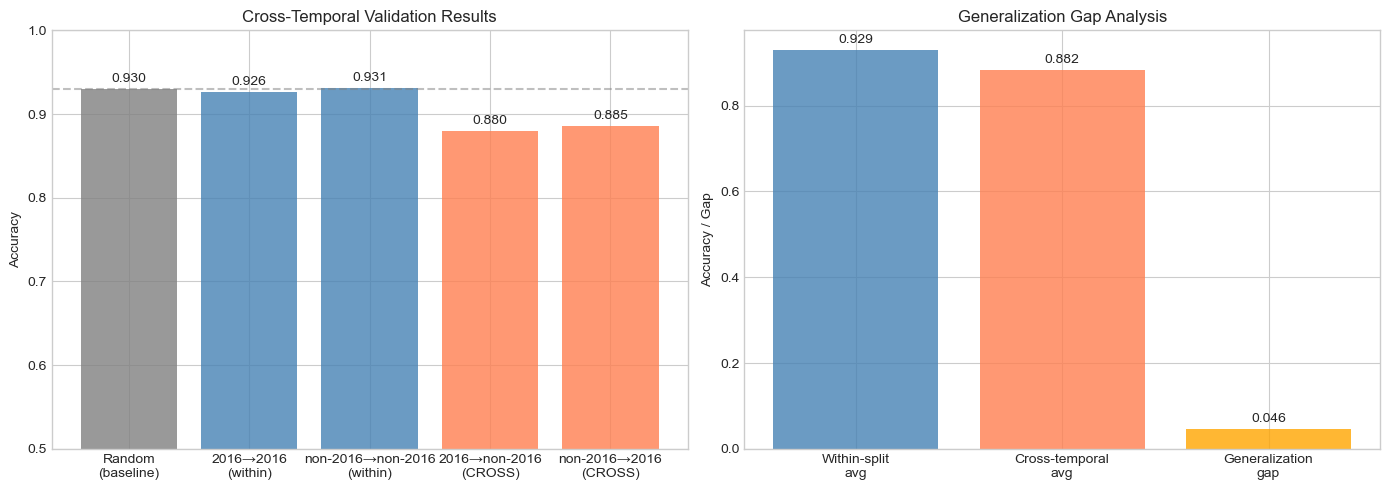


✓ Figure saved to results/figures/cross_temporal_validation.png


In [12]:
# Visualization: Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of accuracies
ax = axes[0]
experiments = ['Random\n(baseline)', '2016→2016\n(within)', 'non-2016→non-2016\n(within)', 
               '2016→non-2016\n(CROSS)', 'non-2016→2016\n(CROSS)']
accuracies = [acc_random, acc_2016_within, acc_non2016_within, 
              acc_2016_to_non2016, acc_non2016_to_2016]
colors = ['gray', 'steelblue', 'steelblue', 'coral', 'coral']

bars = ax.bar(experiments, accuracies, color=colors, alpha=0.8)
ax.axhline(y=acc_random, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Temporal Validation Results')
ax.set_ylim(0.5, 1.0)

# Add value labels
for bar, acc in zip(bars, accuracies):
    ax.annotate(f'{acc:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, acc),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Plot 2: Generalization gap visualization
ax = axes[1]
gap_data = {
    'Metric': ['Within-split\navg', 'Cross-temporal\navg', 'Generalization\ngap'],
    'Value': [avg_within, avg_cross, generalization_gap]
}
colors2 = ['steelblue', 'coral', 'darkred' if generalization_gap > 0.1 else 'orange']
bars2 = ax.bar(gap_data['Metric'], gap_data['Value'], color=colors2, alpha=0.8)
ax.set_ylabel('Accuracy / Gap')
ax.set_title('Generalization Gap Analysis')

for bar, val in zip(bars2, gap_data['Value']):
    ax.annotate(f'{val:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/cross_temporal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/cross_temporal_validation.png")


In [13]:
# Feature importance comparison between models
# What features does each temporal model rely on?

def get_top_features(model, vectorizer, n=15):
    """Get top positive and negative features"""
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]
    
    top_fake_idx = np.argsort(coefs)[-n:][::-1]
    top_real_idx = np.argsort(coefs)[:n]
    
    top_fake = [(feature_names[i], coefs[i]) for i in top_fake_idx]
    top_real = [(feature_names[i], coefs[i]) for i in top_real_idx]
    
    return top_fake, top_real

print("="*70)
print("FEATURE IMPORTANCE COMPARISON")
print("="*70)

fake_2016, real_2016 = get_top_features(model_2016, vectorizer_2016)
fake_non2016, real_non2016 = get_top_features(model_non2016, vectorizer_non2016)

print("\n--- MODEL TRAINED ON 2016 ARTICLES ---")
print("\nTop Fake indicators:")
for feat, coef in fake_2016[:10]:
    print(f"  {feat}: {coef:.3f}")

print("\nTop Real indicators:")
for feat, coef in real_2016[:10]:
    print(f"  {feat}: {coef:.3f}")

print("\n--- MODEL TRAINED ON NON-2016 ARTICLES ---")
print("\nTop Fake indicators:")
for feat, coef in fake_non2016[:10]:
    print(f"  {feat}: {coef:.3f}")

print("\nTop Real indicators:")
for feat, coef in real_non2016[:10]:
    print(f"  {feat}: {coef:.3f}")


FEATURE IMPORTANCE COMPARISON

--- MODEL TRAINED ON 2016 ARTICLES ---

Top Fake indicators:
  october: 4.406
  november: 4.400
  hillary: 4.138
  november 2016: 3.243
  fbi: 2.287
  com: 2.237
  snip: 2.233
  world: 1.998
  11: 1.961
  just: 1.926

Top Real indicators:
  said: -10.540
  president donald: -3.401
  mr: -3.114
  ms: -2.554
  republican: -2.494
  year: -2.438
  thursday: -2.438
  tuesday: -2.327
  percent: -2.203
  monday: -2.181

--- MODEL TRAINED ON NON-2016 ARTICLES ---

Top Fake indicators:
  hillary: 6.062
  president trump: 4.024
  watch: 3.654
  obama: 3.480
  entire: 3.397
  daily: 3.308
  com: 3.197
  rep: 3.076
  today: 3.053
  just: 2.916

Top Real indicators:
  said: -14.246
  president donald: -6.210
  friday: -6.023
  thursday: -6.000
  tuesday: -5.684
  mr: -5.560
  wednesday: -5.384
  monday: -5.355
  sunday: -4.605
  reuters: -4.334


In [14]:
# Feature overlap analysis
fake_features_2016 = set([f[0] for f in fake_2016])
fake_features_non2016 = set([f[0] for f in fake_non2016])
real_features_2016 = set([f[0] for f in real_2016])
real_features_non2016 = set([f[0] for f in real_non2016])

fake_overlap = fake_features_2016 & fake_features_non2016
real_overlap = real_features_2016 & real_features_non2016

print("="*70)
print("FEATURE OVERLAP BETWEEN TEMPORAL MODELS")
print("="*70)

print(f"\nFake news indicators overlap: {len(fake_overlap)}/15")
print(f"  Shared: {sorted(fake_overlap)}")

print(f"\nReal news indicators overlap: {len(real_overlap)}/15")
print(f"  Shared: {sorted(real_overlap)}")

print(f"\n--- UNIQUE TO 2016 MODEL ---")
print(f"  Fake: {sorted(fake_features_2016 - fake_features_non2016)}")
print(f"  Real: {sorted(real_features_2016 - real_features_non2016)}")

print(f"\n--- UNIQUE TO NON-2016 MODEL ---")
print(f"  Fake: {sorted(fake_features_non2016 - fake_features_2016)}")
print(f"  Real: {sorted(real_features_non2016 - real_features_2016)}")


FEATURE OVERLAP BETWEEN TEMPORAL MODELS

Fake news indicators overlap: 5/15
  Shared: ['com', 'fbi', 'hillary', 'just', 'today']

Real news indicators overlap: 8/15
  Shared: ['monday', 'mr', 'ms', 'percent', 'president donald', 'said', 'thursday', 'tuesday']

--- UNIQUE TO 2016 MODEL ---
  Fake: ['11', '27 2016', 'hillary clinton', 'november', 'november 2016', 'october', 'photo', 'posted', 'snip', 'world']
  Real: ['democratic', 'government', 'islamic state', 'nomination', 'republican', 'senate', 'year']

--- UNIQUE TO NON-2016 MODEL ---
  Fake: ['aleppo', 'america', 'daily', 'entire', 'obama', 'president trump', 'rep', 'source', 'stated', 'watch']
  Real: ['friday', 'minister', 'reuters', 'said statement', 'saturday', 'sunday', 'wednesday']


## Part 6: Causal Inference - IPW-Adjusted Evaluation

The raw cross-temporal accuracy is misleading due to the massive label distribution shift:
- 2016 articles: 53.5% fake
- Non-2016 articles: 28.4% fake

**Inverse Propensity Weighting (IPW)** adjusts for this by:
1. Training a propensity model to predict P(environment=2016 | features)
2. Reweighting samples to simulate balanced distributions
3. Computing adjusted accuracy that reveals true generalizability


### IPW Implementation

In [17]:
# === PROPENSITY-WEIGHTED EVALUATION ===
print("="*70)
print("INVERSE PROPENSITY WEIGHTING (IPW) ANALYSIS")
print("="*70)

# 1. Create environment labels (1=2016, 0=non-2016)
env_labels = np.concatenate([
    np.ones(len(df_2016)),
    np.zeros(len(df_non_2016))
])
all_text = np.concatenate([df_2016['text'].values, df_non_2016['text'].values])

print(f"\nTotal samples: {len(all_text):,}")
print(f"  - 2016 environment: {len(df_2016):,}")
print(f"  - Non-2016 environment: {len(df_non_2016):,}")

# 2. Fit propensity model to predict P(environment=2016 | text features)
print("\nTraining propensity model...")
vectorizer_prop = TfidfVectorizer(max_features=1000, stop_words='english')
X_prop = vectorizer_prop.fit_transform(all_text)
propensity_model = LogisticRegression(max_iter=500, random_state=42)
propensity_model.fit(X_prop, env_labels)

# 3. Get propensity scores P(2016 | X) for all samples
propensity_scores = propensity_model.predict_proba(X_prop)[:, 1]

# Split propensity scores by environment
prop_2016 = propensity_scores[:len(df_2016)]
prop_non2016 = propensity_scores[len(df_2016):]

print(f"\nPropensity score statistics:")
print(f"  2016 samples: mean={prop_2016.mean():.3f}, std={prop_2016.std():.3f}")
print(f"  Non-2016 samples: mean={prop_non2016.mean():.3f}, std={prop_non2016.std():.3f}")


INVERSE PROPENSITY WEIGHTING (IPW) ANALYSIS

Total samples: 44,439
  - 2016 environment: 8,954
  - Non-2016 environment: 35,485

Training propensity model...

Propensity score statistics:
  2016 samples: mean=0.766, std=0.232
  Non-2016 samples: mean=0.059, std=0.053


In [18]:
# 4. Compute IPW weights
# For evaluating 2016 model on non-2016 data:
# Weight = P(2016|X) / P(non-2016|X) = P(2016|X) / (1 - P(2016|X))
# This upweights non-2016 samples that "look like" 2016 samples

# Clip propensity scores to avoid extreme weights
eps = 0.01
prop_non2016_clipped = np.clip(prop_non2016, eps, 1 - eps)
weights_non2016 = prop_non2016_clipped / (1 - prop_non2016_clipped)

# Normalize weights to sum to n
weights_non2016_normalized = weights_non2016 * len(weights_non2016) / weights_non2016.sum()

print("="*70)
print("IPW WEIGHTS ANALYSIS")
print("="*70)
print(f"\nWeight statistics for non-2016 samples:")
print(f"  Min: {weights_non2016_normalized.min():.3f}")
print(f"  Max: {weights_non2016_normalized.max():.3f}")
print(f"  Mean: {weights_non2016_normalized.mean():.3f}")
print(f"  Std: {weights_non2016_normalized.std():.3f}")

# 5. Compute IPW-adjusted accuracy for 2016 → non-2016
correct_2016_to_non2016 = (y_pred_2016_to_non2016 == df_non_2016['label'].values).astype(float)
ipw_accuracy_2016_to_non2016 = np.average(correct_2016_to_non2016, weights=weights_non2016_normalized)

# Similarly for non-2016 → 2016
prop_2016_clipped = np.clip(prop_2016, eps, 1 - eps)
weights_2016 = (1 - prop_2016_clipped) / prop_2016_clipped
weights_2016_normalized = weights_2016 * len(weights_2016) / weights_2016.sum()

correct_non2016_to_2016 = (y_pred_non2016_to_2016 == df_2016['label'].values).astype(float)
ipw_accuracy_non2016_to_2016 = np.average(correct_non2016_to_2016, weights=weights_2016_normalized)


IPW WEIGHTS ANALYSIS

Weight statistics for non-2016 samples:
  Min: 0.151
  Max: 26.694
  Mean: 1.000
  Std: 1.113


In [19]:
# 6. Compare raw vs IPW-adjusted accuracies
print("="*70)
print("IPW-ADJUSTED VS RAW ACCURACY COMPARISON")
print("="*70)

print("\n2016 → non-2016:")
print(f"  Raw accuracy:         {acc_2016_to_non2016:.4f}")
print(f"  IPW-adjusted accuracy: {ipw_accuracy_2016_to_non2016:.4f}")
print(f"  Adjustment:           {(ipw_accuracy_2016_to_non2016 - acc_2016_to_non2016)*100:+.2f}%")

print("\nnon-2016 → 2016:")
print(f"  Raw accuracy:         {acc_non2016_to_2016:.4f}")
print(f"  IPW-adjusted accuracy: {ipw_accuracy_non2016_to_2016:.4f}")
print(f"  Adjustment:           {(ipw_accuracy_non2016_to_2016 - acc_non2016_to_2016)*100:+.2f}%")

# Compute TRUE generalization gap using IPW-adjusted accuracies
avg_ipw_cross = (ipw_accuracy_2016_to_non2016 + ipw_accuracy_non2016_to_2016) / 2
true_generalization_gap = avg_within - avg_ipw_cross

print(f"\n{'='*70}")
print("TRUE GENERALIZATION GAP (IPW-Adjusted)")
print(f"{'='*70}")
print(f"\nAverage within-split accuracy:      {avg_within:.4f}")
print(f"Average raw cross-temporal accuracy: {avg_cross:.4f}")
print(f"Average IPW cross-temporal accuracy: {avg_ipw_cross:.4f}")
print(f"\nRaw generalization gap:  {generalization_gap:.4f} ({generalization_gap*100:.1f}%)")
print(f"TRUE generalization gap: {true_generalization_gap:.4f} ({true_generalization_gap*100:.1f}%)")

if true_generalization_gap > 0.1:
    print(f"\n⚠️  SEVERE true generalization gap! Distribution shift was hiding poor transfer.")
elif true_generalization_gap > 0.05:
    print(f"\n⚠️  MODERATE true generalization gap. Some temporal bias masked by distribution shift.")
else:
    print(f"\n✓  Small true generalization gap. Model genuinely transfers across time periods.")


IPW-ADJUSTED VS RAW ACCURACY COMPARISON

2016 → non-2016:
  Raw accuracy:         0.8795
  IPW-adjusted accuracy: 0.8754
  Adjustment:           -0.41%

non-2016 → 2016:
  Raw accuracy:         0.8853
  IPW-adjusted accuracy: 0.8933
  Adjustment:           +0.80%

TRUE GENERALIZATION GAP (IPW-Adjusted)

Average within-split accuracy:      0.9286
Average raw cross-temporal accuracy: 0.8824
Average IPW cross-temporal accuracy: 0.8843

Raw generalization gap:  0.0461 (4.6%)
TRUE generalization gap: 0.0442 (4.4%)

✓  Small true generalization gap. Model genuinely transfers across time periods.


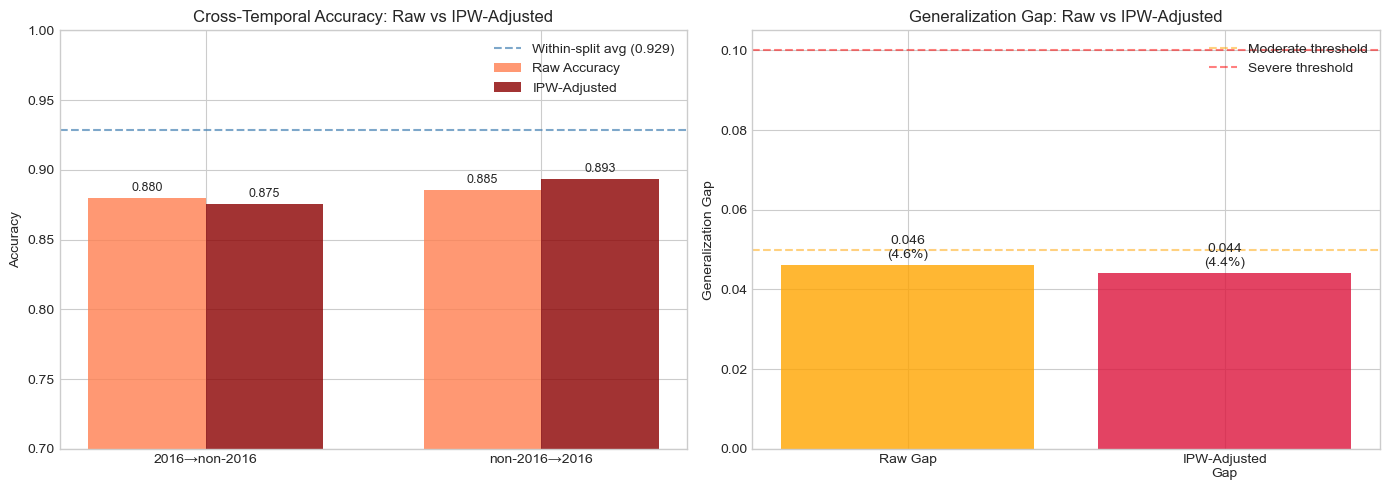


✓ Figure saved to results/figures/ipw_evaluation.png


In [20]:
# 7. Visualize IPW-adjusted results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw vs IPW-adjusted accuracy comparison
ax = axes[0]
x_labels = ['2016→non-2016', 'non-2016→2016']
raw_accs = [acc_2016_to_non2016, acc_non2016_to_2016]
ipw_accs = [ipw_accuracy_2016_to_non2016, ipw_accuracy_non2016_to_2016]

x = np.arange(len(x_labels))
width = 0.35

bars1 = ax.bar(x - width/2, raw_accs, width, label='Raw Accuracy', color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, ipw_accs, width, label='IPW-Adjusted', color='darkred', alpha=0.8)

ax.axhline(y=avg_within, color='steelblue', linestyle='--', alpha=0.7, label=f'Within-split avg ({avg_within:.3f})')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Temporal Accuracy: Raw vs IPW-Adjusted')
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0.7, 1.0)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Plot 2: Generalization gap comparison
ax = axes[1]
gap_labels = ['Raw Gap', 'IPW-Adjusted\nGap']
gaps = [generalization_gap, true_generalization_gap]
colors = ['orange', 'darkred' if true_generalization_gap > 0.1 else 'crimson']

bars = ax.bar(gap_labels, gaps, color=colors, alpha=0.8)
ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Severe threshold')
ax.set_ylabel('Generalization Gap')
ax.set_title('Generalization Gap: Raw vs IPW-Adjusted')
ax.legend()

for bar, gap in zip(bars, gaps):
    ax.annotate(f'{gap:.3f}\n({gap*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, gap),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/ipw_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to results/figures/ipw_evaluation.png")


In [15]:
print("="*70)
print("EXPERIMENT CONCLUSIONS")
print("="*70)

print(f"""
1. DATA SPLIT STATISTICS:
   - Articles with '2016': {len(df_2016):,} ({len(df_2016)/len(df)*100:.1f}%)
   - Articles without '2016': {len(df_non_2016):,} ({len(df_non_2016)/len(df)*100:.1f}%)
   - Fake ratio in 2016 articles: {fake_ratio_2016:.3f}
   - Fake ratio in non-2016 articles: {fake_ratio_non_2016:.3f}

2. WITHIN-SPLIT PERFORMANCE:
   - 2016 → 2016: {acc_2016_within:.4f}
   - non-2016 → non-2016: {acc_non2016_within:.4f}
   - Random baseline: {acc_random:.4f}

3. CROSS-TEMPORAL PERFORMANCE:
   - 2016 → non-2016: {acc_2016_to_non2016:.4f}
   - non-2016 → 2016: {acc_non2016_to_2016:.4f}

4. GENERALIZATION GAP:
   - Gap: {generalization_gap:.4f} ({generalization_gap*100:.1f}%)
""")

if generalization_gap > 0.1:
    print("""
5. INTERPRETATION:
   The SEVERE generalization gap indicates that models trained on one
   time period do NOT generalize well to another. This confirms that:
   
   - The model is learning TIME-SPECIFIC features, not general fake news patterns
   - Features predictive in 2016 (election content) don't transfer
   - The high accuracy on random splits is misleading
   
   This is strong evidence of TEMPORAL BIAS in the WELFake dataset.
""")
elif generalization_gap > 0.05:
    print("""
5. INTERPRETATION:
   The MODERATE generalization gap suggests some temporal bias exists,
   but the model learns some transferable features as well.
""")
else:
    print("""
5. INTERPRETATION:
   The SMALL generalization gap suggests the model learns features that
   transfer reasonably well across time periods. This is encouraging for
   generalization, though other biases may still exist.
""")

print("="*70)


EXPERIMENT CONCLUSIONS

1. DATA SPLIT STATISTICS:
   - Articles with '2016': 8,954 (20.1%)
   - Articles without '2016': 35,485 (79.9%)
   - Fake ratio in 2016 articles: 0.535
   - Fake ratio in non-2016 articles: 0.284

2. WITHIN-SPLIT PERFORMANCE:
   - 2016 → 2016: 0.9263
   - non-2016 → non-2016: 0.9308
   - Random baseline: 0.9302

3. CROSS-TEMPORAL PERFORMANCE:
   - 2016 → non-2016: 0.8795
   - non-2016 → 2016: 0.8853

4. GENERALIZATION GAP:
   - Gap: 0.0461 (4.6%)


5. INTERPRETATION:
   The SMALL generalization gap suggests the model learns features that
   transfer reasonably well across time periods. This is encouraging for
   generalization, though other biases may still exist.

